In [57]:
# import kagglehub

# download dataset
# filepath = kagglehub.competition_download('titanic', output_dir='data')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Exploratory Analysis

In [59]:
df_train = pd.read_csv('data/train.csv')
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [60]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


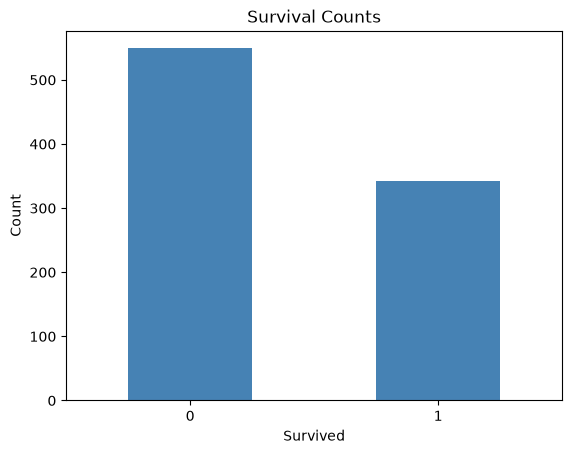

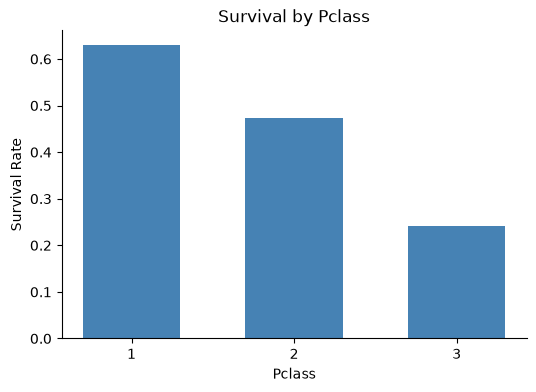

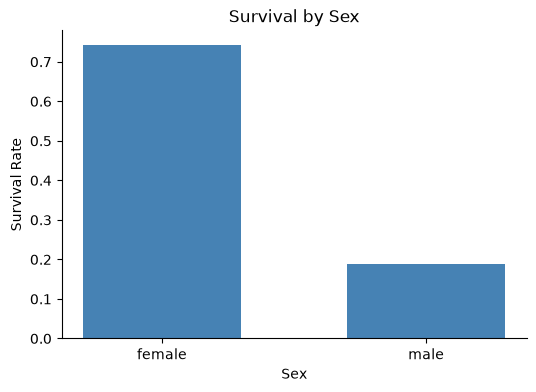

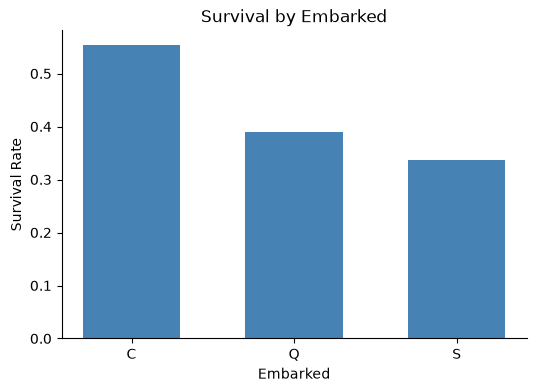

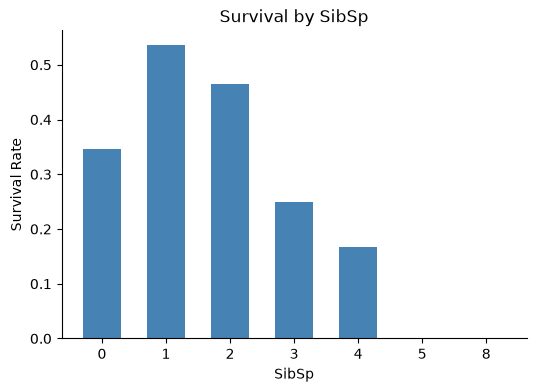

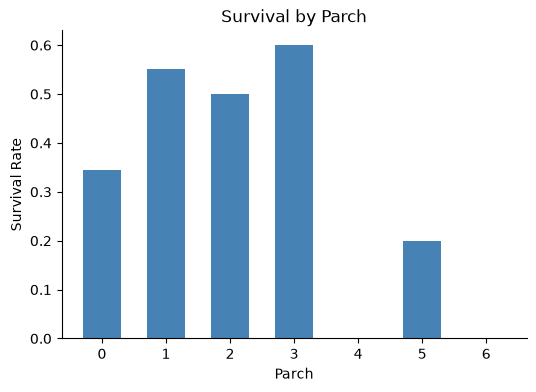

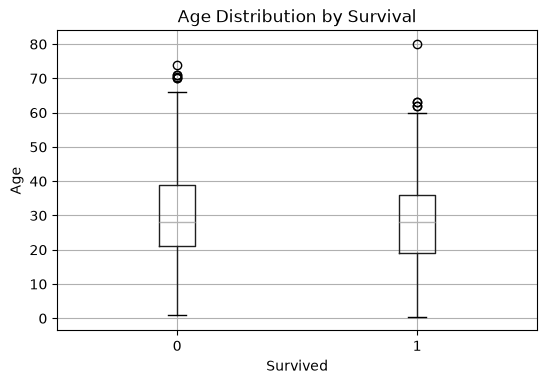

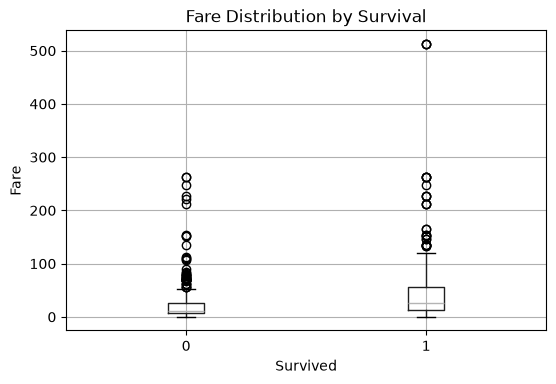

In [61]:
df_train['Survived'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Survival Counts')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

def target_by_cat(x_var: str):
    survived_by_class = df_train.groupby(x_var)['Survived'].mean()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(survived_by_class.index.astype(str), survived_by_class, color='steelblue', width=0.6)
    ax.set_xlabel(x_var)
    ax.set_ylabel('Survival Rate')
    plot_title = "Survival by " + x_var
    ax.set_title(plot_title)
    ax.spines[['top', 'right']].set_visible(False)
    plt.show()

def target_by_num(x_var: str):
    fig, ax = plt.subplots(figsize=(6,4))
    df_train.boxplot(column=x_var, by='Survived', ax=ax)
    ax.set_xlabel('Survived')
    ax.set_ylabel(x_var)
    plot_title = x_var + " Distribution by Survival"
    ax.set_title(plot_title)
    plt.suptitle('')  # removes the default pandas suptitle
    plt.show()

# target variable breakdown
target_by_cat('Pclass')
target_by_cat('Sex')
target_by_cat('Embarked')
target_by_cat('SibSp')
target_by_cat('Parch')

target_by_num('Age')
target_by_num('Fare')

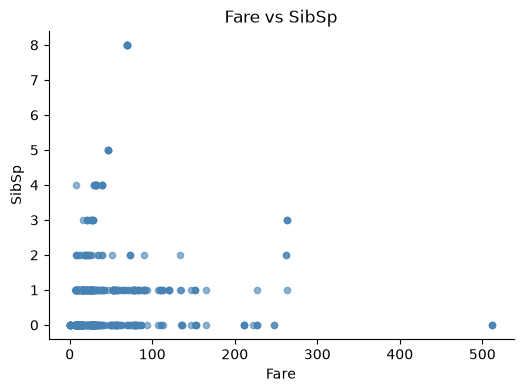

In [62]:
def scatter_x1x2(x1: str, x2:str):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df_train[x1], df_train[x2], color='steelblue', alpha=0.6, s=20)
    ax.set_xlabel(x1)
    ax.set_ylabel(x2)
    plot_title = x1 + " vs " + x2
    ax.set_title(plot_title)
    ax.spines[['top', 'right']].set_visible(False)
    plt.show()

scatter_x1x2('Fare', 'SibSp')

In [73]:
# new features

# extract title from names where possible
df_train['Title'] = df_train['Name'].str.extract(r',\s*([^\.]+)\.')
rare_titles = df_train['Title'].value_counts()[df_train['Title'].value_counts() < 10].index
df_train['Title'] = df_train['Title'].replace(rare_titles, 'Rare')
df_train['Title'] = df_train['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Cabin missingness may be informative
df_train['Cabin_Deck'] = df_train['Cabin'].str[0].fillna('Unknown')

df_train['SibSpByParch'] = df_train['SibSp'] * df_train['Parch']
df_train['AgeByFare'] = df_train['Age'] * df_train['Fare']
df_train['FareByFamily'] = df_train['Fare'] * df_train['SibSpByParch']



In [ ]:
# set up cross-validation and hyper-parameter tuning for XGBoost Classifier
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401 (required to unlock IterativeImputer)
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier

# Age is imputed jointly with Pclass/Fare/SibSp/Parch via MICE 
age_impute_cols = ['Age', 'Pclass', 'Fare', 'SibSp', 'Parch']

# Derived interaction terms get simple median imputation (secondary features,
# NaN only when the underlying Age was NaN pre-imputation).
derived_numeric_cols = ['SibSpByParch', 'AgeByFare', 'FareByFamily']
categorical_cols = ['Pclass', 'Sex', 'Embarked', 'Cabin_Deck', 'Title']

feature_cols = list(dict.fromkeys(age_impute_cols + derived_numeric_cols + categorical_cols))
X = df_train[feature_cols]
y = df_train['Survived']

# each fold fits its own imputer/scaler/encoder on training data only
preprocessor = ColumnTransformer([
    ('age_group', Pipeline([
        ('impute', IterativeImputer(random_state=42)),
        ('scale', StandardScaler()),
    ]), age_impute_cols),
    ('derived_num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), derived_numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop = 'first', handle_unknown='ignore')),
    ]), categorical_cols),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'max_depth': trial.suggest_int('max_depth', 2, 16),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.25, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.25, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.25, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 5, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric': 'logloss',
        'random_state': 42,
    }

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', XGBClassifier(**params)),
    ])

    acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    return acc_scores.mean(), auc_scores.mean()

study = optuna.create_study(directions=['maximize', 'maximize'])
study.optimize(objective, n_trials=25)

[I 2026-09-04 20:46:11,550] A new study created in memory with name: no-name-3817e1b5-7183-416b-a093-6f98a4aa8760
/home/spenc/learning/data-science/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/spenc/learning/data-science/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-09-04 20:46:26,644] Trial 0 finished with values: [0.8147824995292197, 0.8687003360288162] and parameters: {'n_estimators': 1960, 'max_depth': 8, 'max_delta_step': 2, 'learning_rate': 0.13362957150483695, 'subsample': 0.6048815411649394, 'colsample_bytree': 0.6757650358337912, 'colsample_bylevel': 0.6898053517081759, 'colsample_bynode': 0.8

RuntimeError: A single best trial cannot be retrieved from a multi-objective study. Consider using Study.best_trials to retrieve a list containing the best trials.

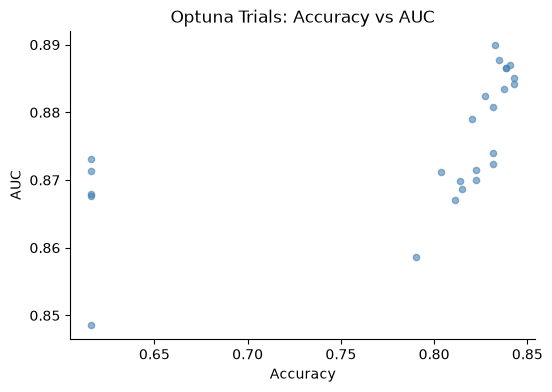

[[0.8147824995292197, 0.8687003360288162], [0.8428535559600778, 0.8841543944335541], [0.6161634548992531, 0.8679799698100222], [0.8316427091833531, 0.8740696122159202], [0.6161634548992531, 0.848590383645934], [0.8406126420187057, 0.8869892838376965], [0.8383654510074697, 0.8865584473989763], [0.8349946644906158, 0.8877295355535695], [0.8226602222082731, 0.8699890289364468], [0.6161634548992531, 0.8676264338639686], [0.8204004770573097, 0.8790467279851709], [0.8372481325717155, 0.8834333598544397], [0.8035653756826313, 0.8711830208748836], [0.8316552633230808, 0.8723418190208237], [0.8428535559600778, 0.8850713954581362], [0.8271232188814261, 0.8824319161250459], [0.8327474734793798, 0.889961985229237], [0.8113991588726381, 0.8670006388529231], [0.8136965664427844, 0.8699052741450499], [0.6161634548992531, 0.8730488535842955], [0.8316427091833531, 0.8807215998412999], [0.8226853304877283, 0.8714959272681767], [0.7901198920343984, 0.8586158666606941], [0.6161634548992531, 0.871330986250

In [88]:
# visualize Pareto front
accs = [t.values[0] for t in study.trials]
aucs = [t.values[1] for t in study.trials]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(accs, aucs, color='steelblue', alpha=0.6, s=20)
ax.set_xlabel('Accuracy')
ax.set_ylabel('AUC')
ax.set_title('Optuna Trials: Accuracy vs AUC')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

print([t.values for t in study.trials])

In [ ]:
# top trials
df_trials = study.trials_dataframe()
top_df = df_trials[(df_trials['values_1'] > 0.88) & (df_trials['values_0'] > 0.84)]
top_df

,number,values_0,values_1,datetime_start,datetime_complete,duration,params_colsample_bylevel,params_colsample_bynode,params_colsample_bytree,params_gamma,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,system_attrs_NSGAIISampler:generation,state
1,1,0.842854,0.884154,2026-09-04 20:46:26.645642,2026-09-04 20:46:38.641047,0 days 00:00:11.995405,0.837763,0.952167,0.721898,0.328421,0.008789,7,9,6,1166,6.340658e-03,0.062951,0.790630,0,COMPLETE
5,5,0.840613,0.886989,2026-09-04 20:46:47.934760,2026-09-04 20:46:59.431343,0 days 00:00:11.496583,0.257095,0.819993,0.985661,0.001486,0.015073,8,7,3,1355,3.909414e-03,0.805170,0.639643,0,COMPLETE
14,14,0.842854,0.885071,2026-09-04 20:48:14.021077,2026-09-04 20:48:33.773385,0 days 00:00:19.752308,0.841436,0.602943,0.495601,0.000064,0.009704,7,7,3,1715,2.979245e-07,0.504459,0.882702,0,COMPLETE


In [93]:
best_params = next(t for t in study.trials if t.number == 14).params

# refit the full pipeline (preprocessing + model) on all training data
best_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(**best_params, eval_metric='logloss', random_state=42)),
])
best_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Pclass','Fare',...,'Embarked','Cabin_Deck','Title']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age_group', ...), ('derived_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``,

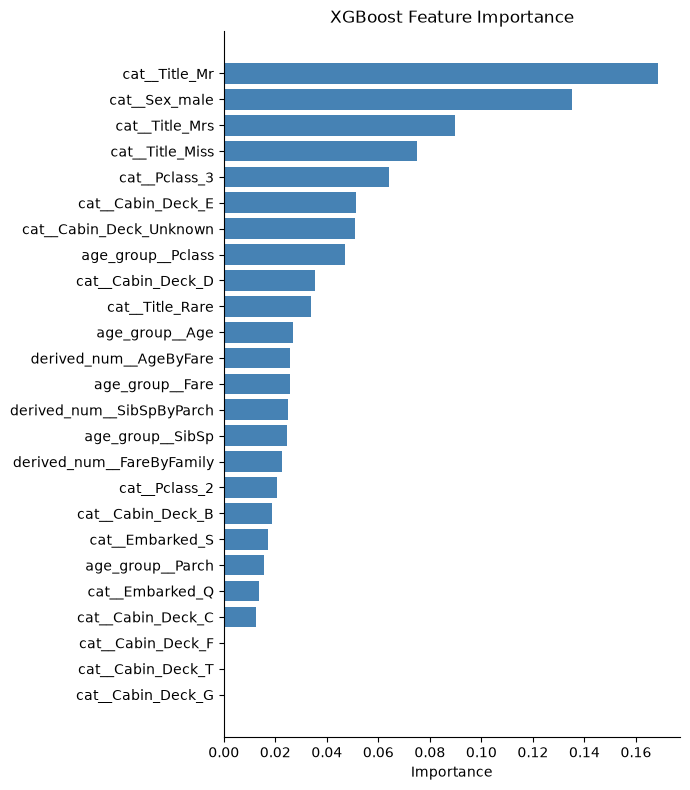

In [94]:
feature_names = best_pipeline.named_steps['preprocess'].get_feature_names_out()
importances = best_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('XGBoost Feature Importance')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()